In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported

In [3]:
# import the ADF test
from statsmodels.tsa.stattools import adfuller

# create a function that returns the necessary metrics to test stationarity
def test_stationarity(timeseries):
    dftest_initial = adfuller(timeseries)
    dfoutput_initial = pd.Series(dftest_initial[0:4], 
          index=['Statistical Test', 
                 'p-value', 
                 '#Lags used', 
                 'Number of observations'
                 ])
    for key, value in dftest_initial[4].items():
        dfoutput_initial['Critical value ' + key] = value
    print(dfoutput_initial)
    print('\n')

In [4]:
data = pd.read_csv("../../Downloads/iex_dam_feb_mar_2026.csv")

In [5]:
data = data.rename(columns={
    'period_start': 'ds',  # Your timestamp
    'purchase_bid': 'y'             # The target value you want to plot (Market Clearing Price)
})
filtered_data = data[[ "ds", "y" ]]
filtered_data['unique_id'] = 'series_1'
filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_95471/3798344235.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['unique_id'] = 'series_1'
/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_95471/3798344235.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])


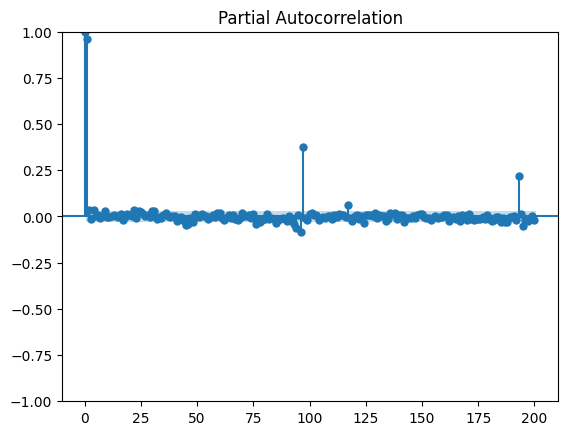

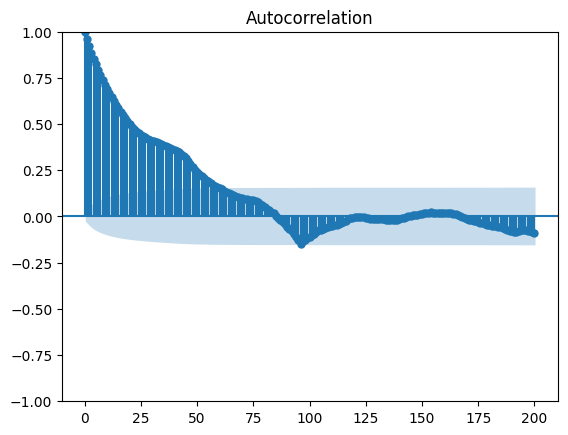

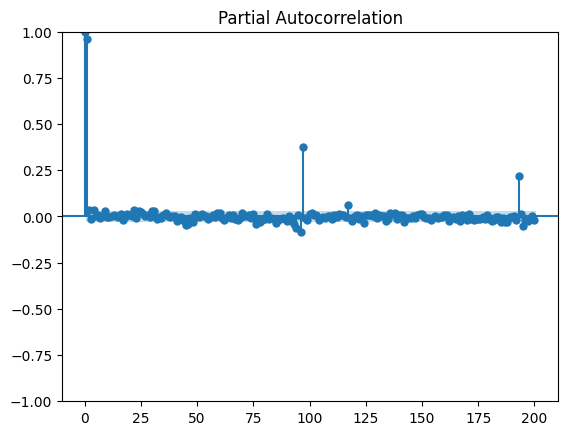

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(filtered_data["y"].diff(96).dropna(), lags=200)
plot_pacf(filtered_data["y"].diff(96).dropna(), lags=200)

In [59]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA, ARIMA

### predict a day in future

In [61]:
horizon = 96*7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96),
    SeasonalNaive(season_length=96)
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=filtered_data)
preds = sf.predict(h=horizon)

In [62]:
preds

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,2026-03-26 00:00:00,15093.4,16790.849037,16273.346875,15427.7
1,series_1,2026-03-26 00:15:00,15093.4,16790.849037,16273.346875,16174.7
2,series_1,2026-03-26 00:30:00,15093.4,16790.849037,16273.346875,16597.6
3,series_1,2026-03-26 00:45:00,15093.4,16790.849037,16273.346875,16798.1
4,series_1,2026-03-26 01:00:00,15093.4,16790.849037,16273.346875,17012.3
...,...,...,...,...,...,...
667,series_1,2026-04-01 22:45:00,15093.4,16790.849037,16273.346875,15614.6
668,series_1,2026-04-01 23:00:00,15093.4,16790.849037,16273.346875,15436.1
669,series_1,2026-04-01 23:15:00,15093.4,16790.849037,16273.346875,15216.3
670,series_1,2026-04-01 23:30:00,15093.4,16790.849037,16273.346875,15135.6


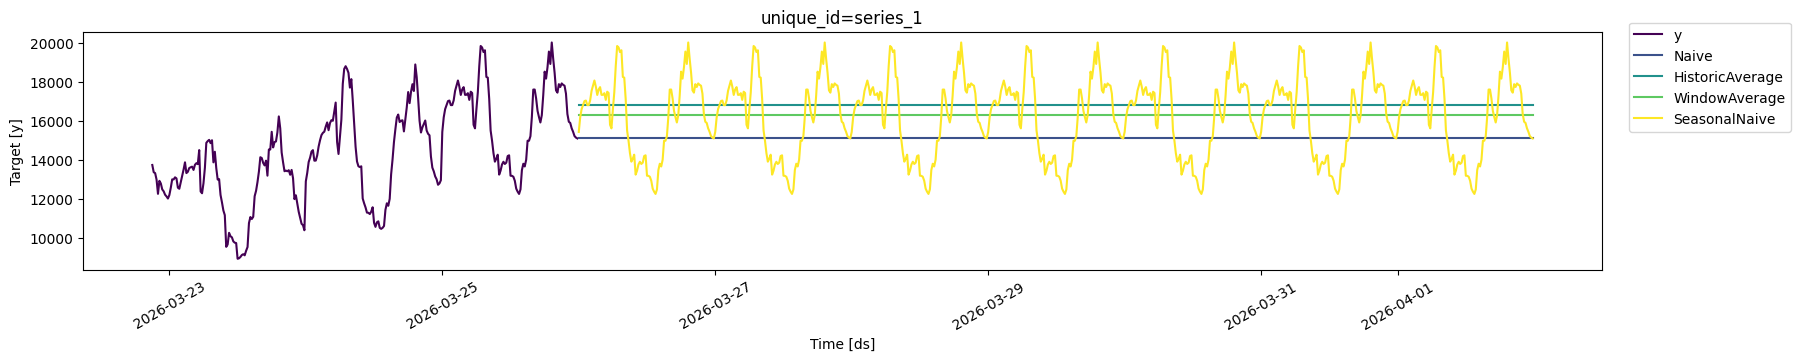

In [63]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=300, 
    palette="viridis")

In [64]:
test = filtered_data.tail(horizon)
train = filtered_data.drop(test.index).reset_index(drop=True)

In [65]:
sf.fit(df=train)

preds = sf.predict(h=horizon)

eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [66]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,mae,2568.544643,3239.313759,2073.073493,1576.517857


In [67]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,2568.544643,3239.313759,2073.073493,1576.517857


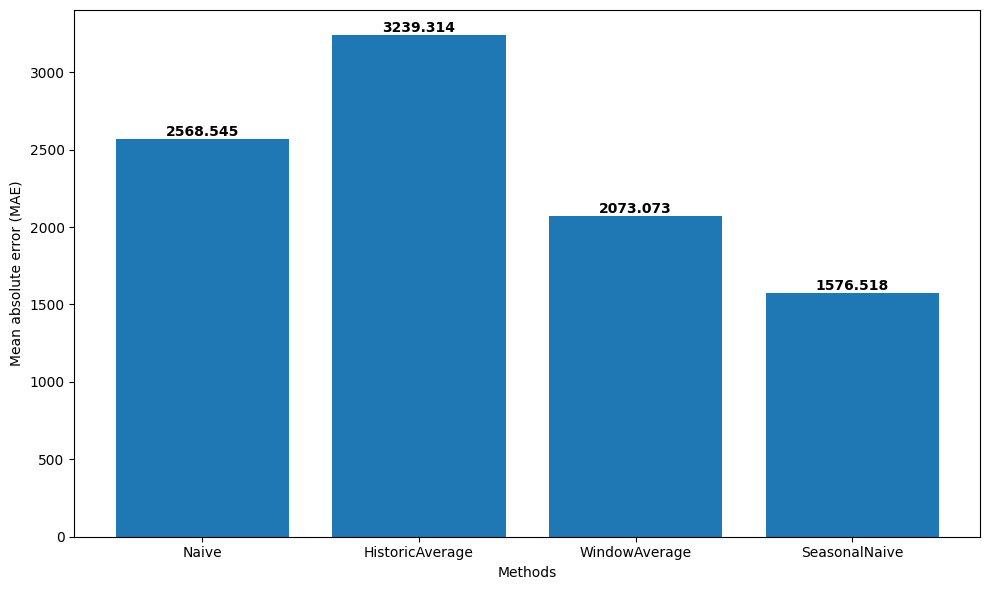

In [68]:
methods = evaluation.columns[1:].tolist()  
values = evaluation.iloc[0, 1:].tolist() 

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

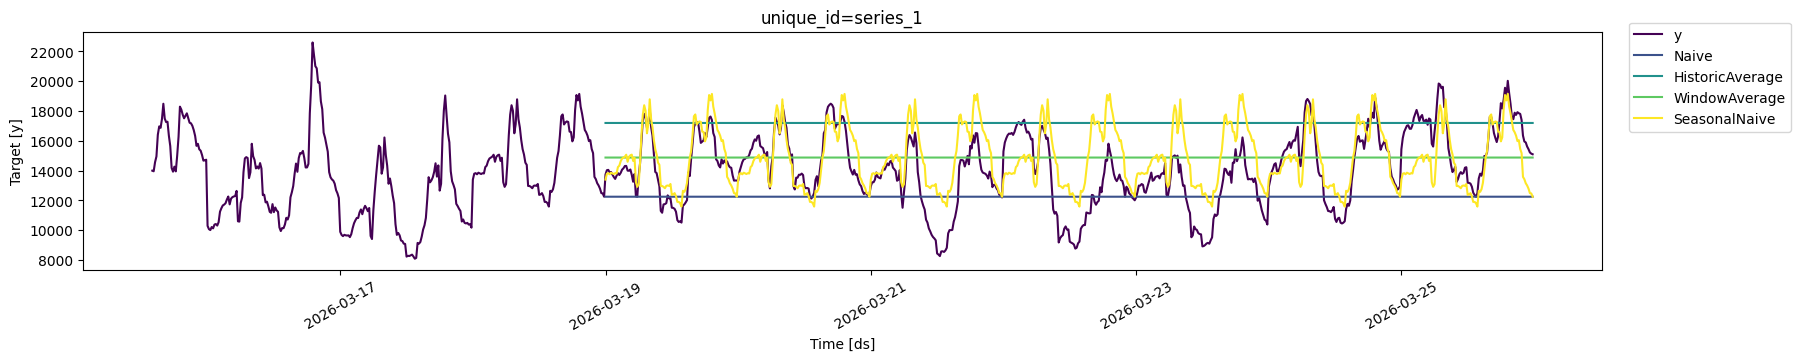

In [71]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

## Real business

In [72]:
models = [
    # AutoARIMA(seasonal=False, alias="ARIMA"),
    # AutoARIMA(season_length=96, seasonal=True)
    # ARIMA(order=(2,1,3), season_length=96, seasonal_order=(3, 1, 1), alias="SARIMA (2,1,3,3,1,1,96)"),
    # ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)")
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

,unique_id,metric,"SARIMA (1,1,1,1,1,1,96)",Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,mae,2198.060015,2568.544643,3239.313759,2073.073493,1576.517857


In [73]:
# arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,unique_id,metric,"SARIMA (1,1,1,1,1,1,96)",Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,mae,2198.060015,2568.544643,3239.313759,2073.073493,1576.517857


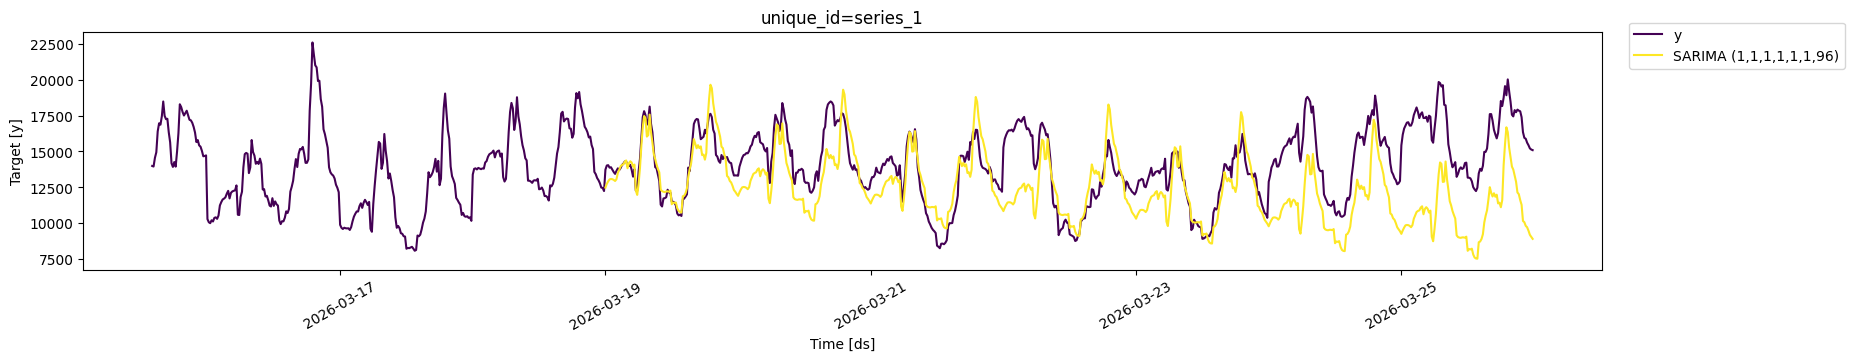

In [74]:
plot_series(
    df=filtered_data, 
    forecasts_df=arima_eval_df[["unique_id", "ds", "SARIMA (1,1,1,1,1,1,96)"]], 
    max_insample_length=1000, 
    palette="viridis")

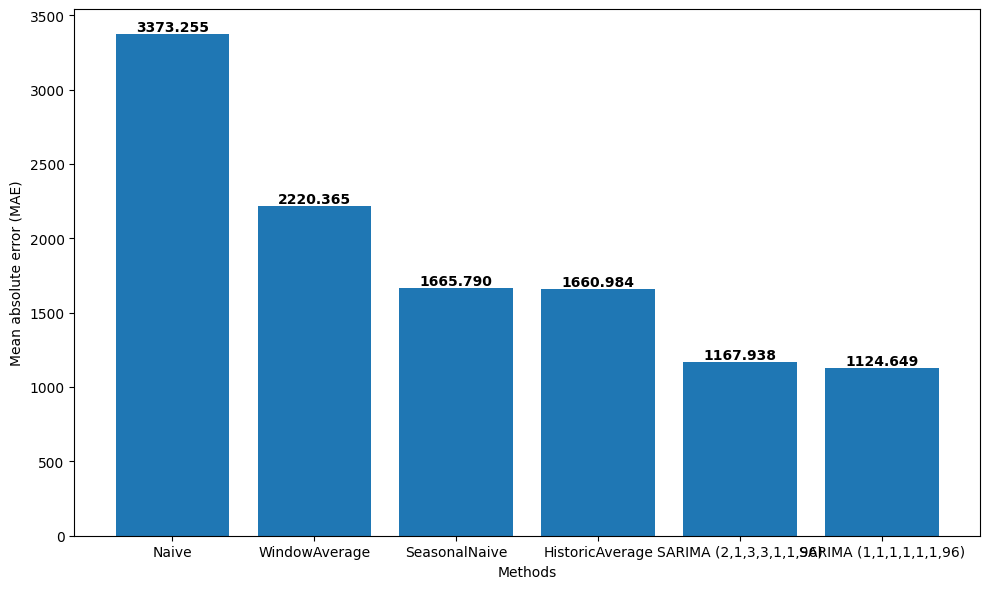

In [36]:
methods = arima_eval.columns[1:].tolist()  
values = arima_eval.iloc[0, 1:].tolist() 

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

In [ ]:
SARIMA(0,0,1)(0,1,1)96 -> 2223.741567
SARIMA(4,1,1)(0,0,0)1 -> 2632.164
SARIMA(2,1,3)(3,1,1)96 -> 1167.938
SARIMA(1,1,1)(1,1,1)96 -> 1124.649

In [39]:
models = [
    SeasonalNaive(season_length=96),
    # AutoARIMA(seasonal=False, alias="ARIMA"),
    # AutoARIMA(season_length=96, seasonal=True)
    # ARIMA(order=(2,1,3), season_length=96, seasonal_order=(3, 1, 1), alias="SARIMA (2,1,3,3,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)")
]

sf = StatsForecast(models=models, freq="15min")
cv_df = sf.cross_validation(
    h=horizon, # 7 days
    df=filtered_data,
    n_windows=7,
    step_size=horizon,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,"SARIMA (1,1,1,1,1,1,96)"
0,series_1,2026-03-19 00:00:00,2026-03-18 23:45:00,13733.9,13393.8,12485.049962
1,series_1,2026-03-19 00:15:00,2026-03-18 23:45:00,14021.4,13788.8,12743.385227
2,series_1,2026-03-19 00:30:00,2026-03-18 23:45:00,14045.6,13824.5,12922.037422
3,series_1,2026-03-19 00:45:00,2026-03-18 23:45:00,13872.2,13748.7,13051.416936
4,series_1,2026-03-19 01:00:00,2026-03-18 23:45:00,13903.2,13854.8,13084.685783


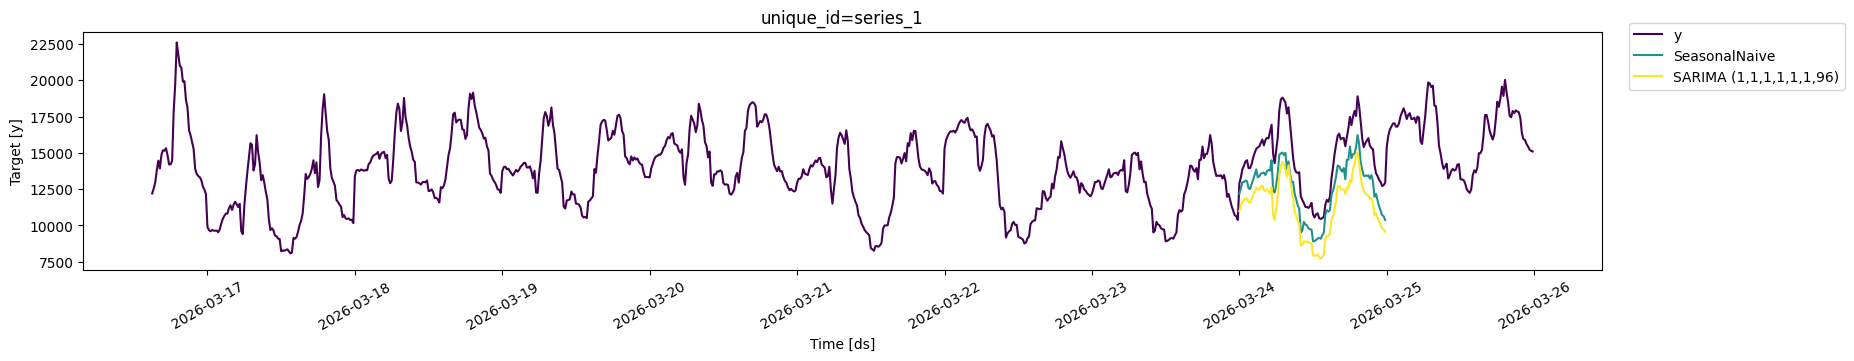

In [57]:
plot_series(
    df=filtered_data, 
    forecasts_df=cv_df[96*5:96*6].drop(["y", "cutoff"], axis=1), 
    max_insample_length=900, 
    palette="viridis")

In [43]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,SeasonalNaive,"SARIMA (1,1,1,1,1,1,96)"
0,mae,1505.95372,1380.282264


In [46]:
cv_df#[cv_df.ds.str.contains("2026-03-23")]

,unique_id,ds,cutoff,y,SeasonalNaive,"SARIMA (1,1,1,1,1,1,96)"
0,series_1,2026-03-19 00:00:00,2026-03-18 23:45:00,13733.9,13393.8,12485.049962
1,series_1,2026-03-19 00:15:00,2026-03-18 23:45:00,14021.4,13788.8,12743.385227
2,series_1,2026-03-19 00:30:00,2026-03-18 23:45:00,14045.6,13824.5,12922.037422
3,series_1,2026-03-19 00:45:00,2026-03-18 23:45:00,13872.2,13748.7,13051.416936
4,series_1,2026-03-19 01:00:00,2026-03-18 23:45:00,13903.2,13854.8,13084.685783
...,...,...,...,...,...,...
667,series_1,2026-03-25 22:45:00,2026-03-24 23:45:00,15614.6,13140.4,14018.554530
668,series_1,2026-03-25 23:00:00,2026-03-24 23:45:00,15436.1,12994.0,13836.834132
669,series_1,2026-03-25 23:15:00,2026-03-24 23:45:00,15216.3,12712.3,13569.820398
670,series_1,2026-03-25 23:30:00,2026-03-24 23:45:00,15135.6,12780.6,13546.964002


In [56]:
# 1. Filter for March 23rd
# Since 'ds' is already a datetime object from your previous steps
march_23_df = cv_df[cv_df['ds'].dt.date == pd.to_datetime('2026-03-24').date()]

# 2. Calculate MAE for y and SARIMA
from sklearn.metrics import mean_absolute_error

# Use the exact column name from your SARIMA model
mae_23rd = mean_absolute_error(march_23_df['y'], march_23_df['SARIMA (1,1,1,1,1,1,96)'])

print(f"MAE for March 23rd: {mae_23rd:.4f}")

# Optional: View the first few rows of the filtered data
march_23_df.head()

MAE for March 23rd: 3239.3535


,unique_id,ds,cutoff,y,SeasonalNaive,"SARIMA (1,1,1,1,1,1,96)"
480,series_1,2026-03-24 00:00:00,2026-03-23 23:45:00,12888.3,12182.8,10986.142660
481,series_1,2026-03-24 00:15:00,2026-03-23 23:45:00,13323.2,12557.3,11367.643567
482,series_1,2026-03-24 00:30:00,2026-03-23 23:45:00,13881.2,12990.0,11644.758368
483,series_1,2026-03-24 00:45:00,2026-03-23 23:45:00,14104.4,12985.0,11747.057088
484,series_1,2026-03-24 01:00:00,2026-03-23 23:45:00,14416.5,13094.5,11881.274987
